In [1]:
#%reload_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import h5py
import emcee

import holodeck as holo
from Nanograv_15_year_constraints import interpolate_lumdistmax_Nano_15, Detectable_Sources_Lumdist, get_UL_vs_freq
from Nanograv_15_year_constraints import get_ss_GW_strain, get_bg_GW_strain, dl_from_strain
from holodeck import sams
from holodeck import utils, plot, cosmo
from holodeck.constants import MSOL, YR, MPC, NWTG, SPLC
#from astropy import coordinates
holo.log.setLevel(holo.log.ERROR)

In [2]:
sam = sams.Semi_Analytic_Model(shape=10,gsmf=sams.components.GSMF_Schechter(phi0=-1))

In [3]:
#Generate frequency bins according to simulation
OBS_DUR = 10.0 * YR    # duration of PTA observations in [sec], which determines the Fourier frequency basis
NUM_FREQS = 40  # number of frequency bins
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
NUM_REALS = 1000  # Number of 'realizations' to generate
NUM_LOUDEST = 4  # Number of 'loudest' binaries to generate in each frequency bin
print(f"Number of frequency bins: {fobs.size}")
print(f"  between [{fobs[0]*YR:.2f}, {fobs[-1]*YR:.2f}] 1/yr")
print(f"          [{fobs[0]*1e9:.2f}, {fobs[-1]*1e9:.2f}] nHz")

Number of frequency bins: 40
  between [0.10, 4.00] 1/yr
          [3.17, 126.75] nHz


In [4]:
hc_ss, hc_bg, par_ss, par_bg = sam.gwb(fobs_edges, realize=NUM_REALS, loudest=NUM_LOUDEST, params=True)

14:30:14 ERROR : Warning, significant change in number-mass!  mass: 1.66e+01 ==> 2.88e+01 || change = 7.3335e-01 [sam.py:static_binary_density]


In [5]:
Chirp_Mass_ss = utils.chirp_mass_mtmr(par_ss[0],par_ss[1]) #Chirp Mass in grams

[Text(0, 0.5, 'Chirp Mass $M_c$ [M$_{\\odot}$]'),
 Text(0.5, 0, 'GW Frequency [nHz]')]

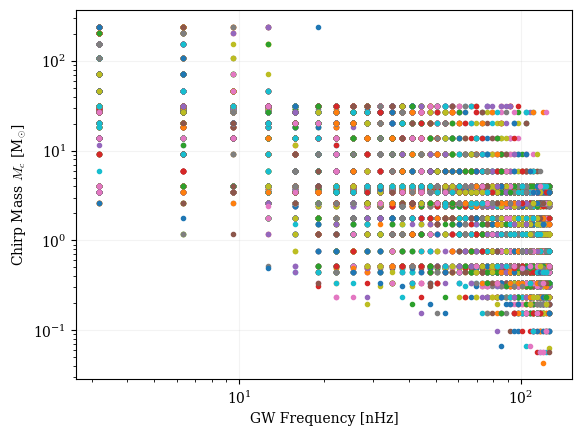

In [6]:
for i in range(NUM_LOUDEST):
    plt.loglog(fobs*10**9,Chirp_Mass_ss[:,:,i]/(10**9*MSOL),'.')
plt.gca().set(ylabel='Chirp Mass $M_c$ [M$_{\\odot}$]', xlabel='GW Frequency [nHz]')

In [8]:
h_ss = get_ss_GW_strain(fobs,fobs_edges,hc_ss) #Get GW strain
#Lumdist_h = dl_from_strain(fobs,h_ss,par_ss[3],mchirp = Chirp_Mass_ss) #Calculate Luminosity distance from GW strain
Lumdist = cosmo.luminosity_distance(par_ss[3]).cgs.value/MPC #Calculate Luminosity distance through Cosmopy

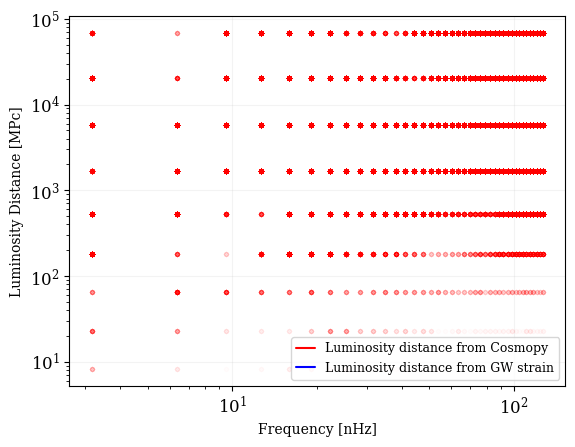

In [10]:
for i in range(NUM_LOUDEST):
    plt.loglog(fobs*10**9,Lumdist[:,:,i],'.',color='red',alpha=0.01)
    #plt.loglog(fobs*10**9,Lumdist_h[:,:,i],'.',color='blue',alpha=0.01)
plt.plot([],[],label='Luminosity distance from Cosmopy',color='red')
plt.plot([],[],label='Luminosity distance from GW strain',color='blue')
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.ylabel('Luminosity Distance [MPc]')
plt.xlabel('Frequency [nHz]')
plt.legend(fontsize='9')
#plt.savefig('Luminosity Distance for all configurations.png')

In [11]:
Upper_boundsL_R_eff = interpolate_lumdistmax_Nano_15(fobs,par_ss[3],Chirp_Mass_ss,model='r_eff')
Upper_boundsL_All_Sky = interpolate_lumdistmax_Nano_15(fobs,par_ss[3],Chirp_Mass_ss,model='all_sky')
Upper_boundsL_R_cst = interpolate_lumdistmax_Nano_15(fobs,0,1e9*MSOL*np.ones(np.shape(hc_ss)),model='r_eff')
Upper_boundsL_A_cst = interpolate_lumdistmax_Nano_15(fobs,0,1e9*MSOL*np.ones(np.shape(hc_ss)),model='all_sky')

In [13]:
figdatafile = "../../data/dist_ul_plot_data.npz"
npzfile = np.load(figdatafile)
xedges = npzfile['xedges']
d_eff_freq = npzfile['d_eff_freq']
d_worst_freq = npzfile['d_worst_freq']
d_best_freq = npzfile['d_best_freq']
dist_UL_freq = npzfile['dist_UL_freq']


In [14]:
plt.step(10**xedges, np.concatenate((dist_UL_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:red", label="15-year")
for i in range(NUM_REALS):
    for j in range(NUM_LOUDEST):
        plt.scatter(fobs,Upper_boundsL_A_cst[:,i,j])
plt.ylabel('Single source maximal strain')
plt.xlabel('Frequency [nHz]')
plt.yscale('log')
plt.xscale('log')
plt.show()
plt.step(10**xedges, np.concatenate((d_eff_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:red", label="15-year")
for i in range(NUM_REALS):
    for j in range(NUM_LOUDEST):
        plt.scatter(fobs,Upper_boundsL_R_cst[:,i,j])
plt.ylabel('Single source maximal strain')
plt.xlabel('Frequency [nHz]')
plt.yscale('log')
plt.xscale('log')
plt.show()


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001EC3241AF70> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



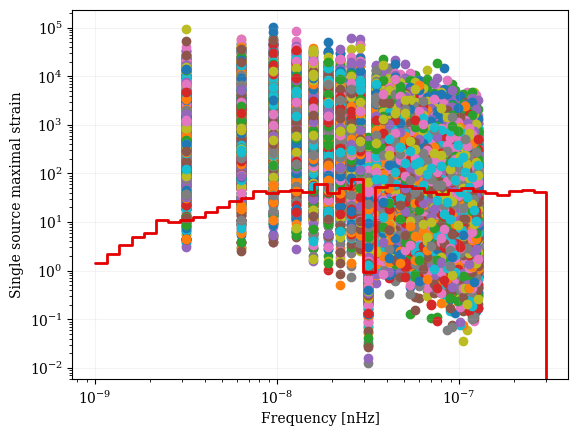

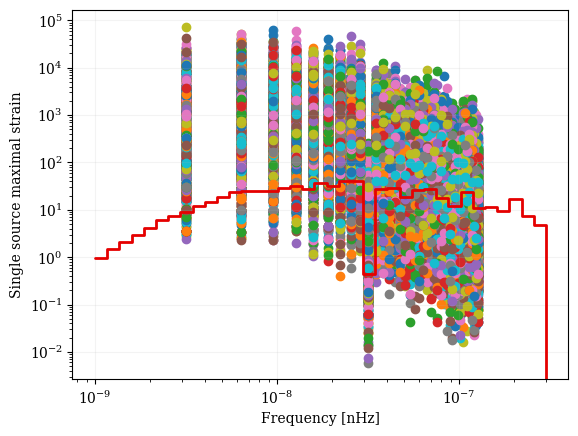

In [54]:
plt.step(10**xedges, np.concatenate((d_eff_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:red", label="15-year")
for i in range(NUM_REALS):
    for j in range(NUM_LOUDEST):
        plt.scatter(fobs,Upper_boundsL_R_eff[:,i,j])
plt.ylabel('Single source maximal strain')
plt.xlabel('Frequency [nHz]')
plt.yscale('log')
plt.xscale('log')
plt.show()
plt.step(10**xedges, np.concatenate((dist_UL_freq, [0.0,])), where='post',
             ls='-', lw=2, marker='', alpha=1.0, color="xkcd:red", label="15-year")
for i in range(NUM_REALS):
    for j in range(NUM_LOUDEST):
        plt.scatter(fobs,Upper_boundsL_All_Sky[:,i,j])
plt.ylabel('Single source maximal strain')
plt.xlabel('Frequency [nHz]')
plt.yscale('log')
plt.xscale('log')
plt.show()


In [32]:
FilteredLumdist_A, FilteredFreqs_A, corresponding_lower_limit_A, realization_number_A, frequency_of_SMBHB_A = Detectable_Sources_Lumdist2(fobs,Lumdist,Upper_boundsL_All_Sky)
FilteredLumdist_R_eff, FilteredFreqs_R_eff, corresponding_lower_limit_R_eff, realization_number_R_eff, frequency_of_SMBHB_R_eff = Detectable_Sources_Lumdist2(fobs,Lumdist,Upper_boundsL_R_eff)

In [34]:
np.shape(FilteredLumdist_A)

(24114,)

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

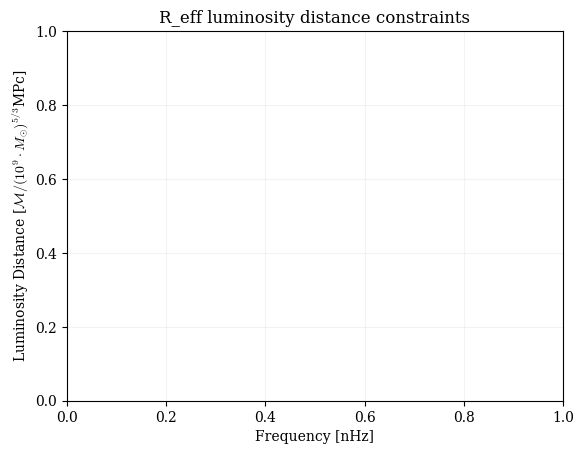

In [33]:
plt.title('R_eff luminosity distance constraints')
plt.xlabel('Frequency [nHz]')
plt.ylabel('Luminosity Distance [$\\mathcal{M}/(10^9 \\cdot M_{\\odot})^{5/3}$MPc]')
for i in np.arange(NUM_LOUDEST):
    plt.loglog(FilteredFreqs_R_eff[:,:,i]*10**9,FilteredLumdist_R_eff[:,:,i],'.',color='red')
    plt.loglog(FilteredFreqs_R_eff[:,:,i]*10**9,corresponding_lower_limit_R_eff[:,:,i],'.',color='green')
#plt.loglog([],[],label='strain of simulated SMBHB',color='red')
#plt.loglog([],[],label='Corresponding lower strain bound of simulated SMBHB',color='green')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize='9')
#plt.savefig('Constrained Distance')

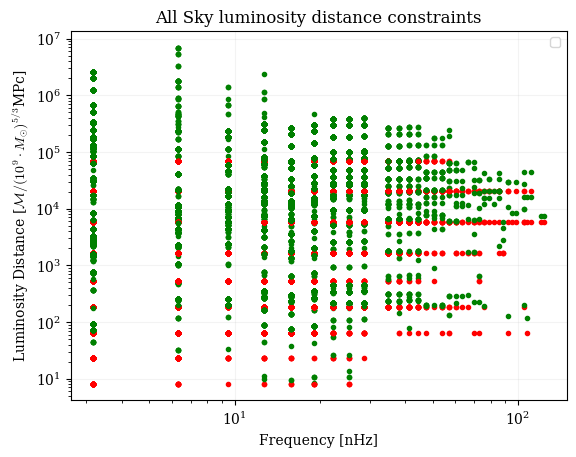

In [17]:
plt.title('All Sky luminosity distance constraints')
plt.xlabel('Frequency [nHz]')
plt.ylabel('Luminosity Distance [$\\mathcal{M}/(10^9 \\cdot M_{\\odot})^{5/3}$MPc]')
for i in np.arange(NUM_LOUDEST):
    plt.loglog(FilteredFreqs_A[:,:,i]*10**9,FilteredLumdist_A[:,:,i],'.',color='red')
    plt.loglog(FilteredFreqs_A[:,:,i]*10**9,corresponding_lower_limit_A[:,:,i],'.',color='green')
#plt.loglog([],[],label='strain of simulated SMBHB',color='red')
#plt.loglog([],[],label='Corresponding lower strain bound of simulated SMBHB',color='green')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize='9')
#plt.savefig('Constrained Distance')

In [58]:
c1, b1 = np.histogram(realization_number_R_eff,bins=NUM_REALS)
success1 = 0
total1 = len(c1)
for i in c1:
    if i != 0:
        success1 += 1
c2, b2 = np.histogram(frequency_of_SMBHB_R_eff,bins=NUM_FREQS)
success2 = 0
total2 = len(c2)
for i in c2:
    if i!= 0:
        success2 += 1
c3, b3 = np.histogram(realization_number_A,bins=NUM_REALS)
success3 = 0
total3 = len(c3)
for i in c3:
    if i != 0:
        success3 += 1
c4, b4 = np.histogram(frequency_of_SMBHB_A,bins=NUM_FREQS)
success4 = 0
total4 = len(c4)
for i in c4:
    if i!= 0:
        success4 += 1

There is a 71.5% chance to detect a single source, with a mean number of detections of 1.233.


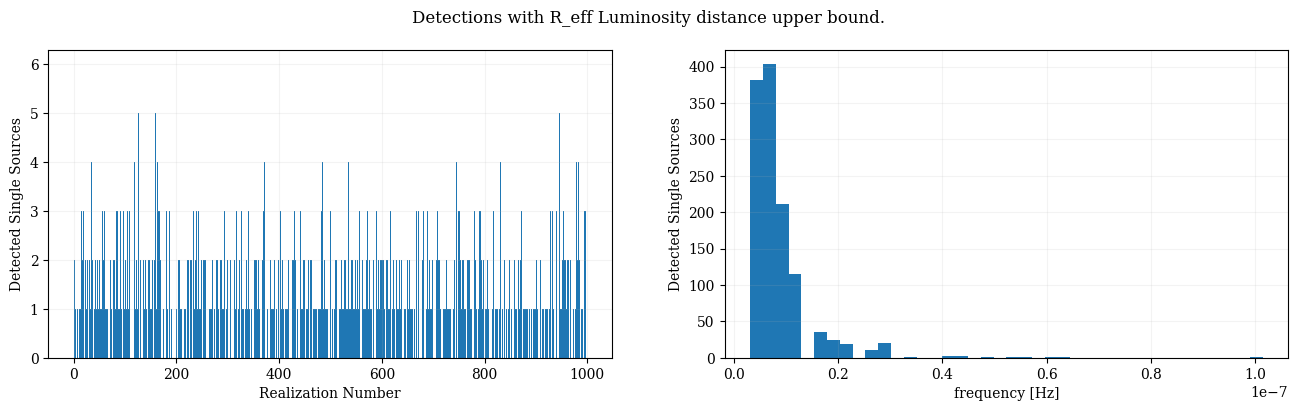

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Detections with R_eff Luminosity distance upper bound.')
axs[0].hist(realization_number_R_eff,bins=NUM_REALS)
axs[0].set_xlabel('Realization Number')
axs[0].set_ylabel('Detected Single Sources')
axs[1].hist(frequency_of_SMBHB_R_eff,bins=NUM_FREQS)
axs[1].set_xlabel('frequency [Hz]')
axs[1].set_ylabel('Detected Single Sources')
print(f'There is a {100*success1/total1}% chance to detect a single source, with a mean number of detections of {np.mean(c1)}.')
plt.savefig('Figures/Single_Sources_Data',bbox_inches='tight')

There is a 47.3% chance to detect a single source, with a mean number of detections of 0.61.


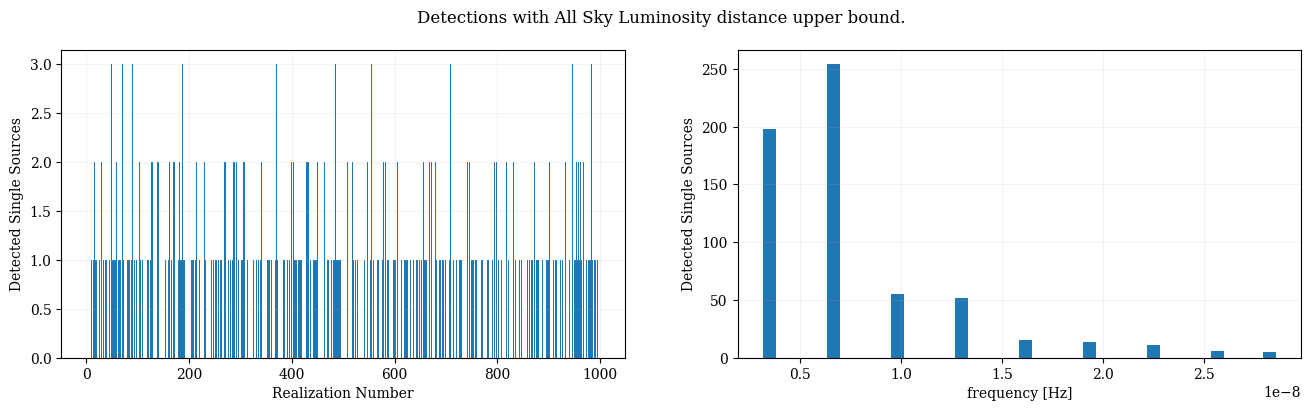

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Detections with All Sky Luminosity distance upper bound.')
axs[0].hist(realization_number_A,bins=NUM_REALS)
axs[0].set_xlabel('Realization Number')
axs[0].set_ylabel('Detected Single Sources')
axs[1].hist(frequency_of_SMBHB_A,bins=NUM_FREQS)
axs[1].set_xlabel('frequency [Hz]')
axs[1].set_ylabel('Detected Single Sources')
print(f'There is a {100*success3/total3}% chance to detect a single source, with a mean number of detections of {np.mean(c3)}.')
plt.savefig('Figures/Single_Sources_Data',bbox_inches='tight')